# Sydney Property Sale Price Prediction
### A Machine Learning Case Study Across Mosman, Parramatta and Campbelltown

**Before running anything else:** run the setup cell below once. It creates the
`data/` and `figures/` folders next to this notebook (if they don't already exist) and
tells you exactly where to put the spreadsheet.


In [1]:
import os

os.makedirs("data", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("app", exist_ok=True)

expected_path = r"C:\Users\Rohan\sydney prop\data\Sydney_Property_Sales_Collected.xlsx"
if os.path.exists(expected_path):
   print(f"Found dataset at: {os.path.abspath(expected_path)}")
else:
    print(f"Dataset NOT found at: {os.path.abspath(expected_path)}")

Found dataset at: C:\Users\Rohan\sydney prop\data\Sydney_Property_Sales_Collected.xlsx


---
## Part 1 — Problem Definition and Data Collection

### 1.1 Suburb selection and motivation

Three Sydney suburbs were selected to represent **substantially different housing
markets** along the dimensions of location, socio-economic profile, and typical dwelling
type:

| Suburb | Region | Character | Why selected |
|---|---|---|---|
| **Mosman** | Lower North Shore (harbourside) | Prestige, low-density, harbour views, large blocks | Represents the top end of the Sydney market, where price is driven heavily by land scarcity, views and prestige rather than by internal features alone |
| **Parramatta** | Central-west Sydney (metro CBD) | Established middle-ring suburb, mixed housing stock, strong transport links | Represents the broad "middle market" — the suburb type most home buyers actually transact in |
| **Campbelltown** | South-west Sydney (outer metro) | Growth corridor, larger/newer housing, more affordable | Represents the affordable end of the market, where land is more available and prices are more sensitive to dwelling size than to location scarcity |

These three suburbs were chosen because, together, they span roughly a **16-fold range in
median sale price** (see Part 2), which makes suburb-level effects a first-order feature
for the prediction problem rather than a nuisance variable — an interesting and realistic
challenge for a housing price model.

### 1.2 Data collection process

Sold-listing data was manually collected from **Domain.com.au** sold-listing pages for
each suburb (see the *Sources* sheet in the accompanying spreadsheet for the exact URLs
used). For each property we recorded every field visible on the sold-listing search-result
card: address, sale price, sale date, property type, bedrooms, bathrooms, car spaces, land
size (where shown), and the listing source page. A minimum of 30 properties per suburb was
required; **40 properties per suburb (120 total)** were collected to give some buffer
against later data-quality issues.

### 1.3 Data quality, limitations and bias

Honesty about data quality is essential before any modelling is attempted:

- **Fields that could not be populated.** Domain's sold-listing *search-result* cards
  (as opposed to the full listing page, which is often removed after sale) do not expose
  building size, storeys, year built, or amenity flags (pool, garden, air-conditioning,
  study, dishwasher, solar), the agent's text description, or the sale method. These
  columns are present in the spreadsheet as placeholders but are **100% empty** for all
  120 rows. This is disclosed explicitly rather than fabricated — the dataset's `README`
  sheet states that "missing fields are intentionally blank and should not be fabricated."
  This is the single biggest limitation of the dataset and is revisited in Parts 2, 4 and 6.
- **Partial missingness.** `land_size_m2` is missing for **24%** of rows (mostly in
  Mosman, where many sales are strata/semi-detached dwellings without a distinct lot size),
  and `car_spaces` is missing for 5% of rows.
- **Price-withheld listings excluded.** Some sold listings on Domain do not disclose a
  price; these were excluded by construction, since sale price is the prediction target.
  This introduces a **survivorship-style bias**: our dataset systematically excludes
  whichever properties (often off-market or high-value private sales) had prices withheld,
  which may differ systematically from disclosed sales.
- **Sampling bias.** Properties were collected from the most recent pages of each
  suburb's sold-listing feed, so the sample is weighted toward mid-2025 to mid-2026 sales
  and toward houses (109/120) over other dwelling types — apartments and townhouses are
  under-represented.
- **Small sample size.** At 120 rows (40 per suburb), the dataset is small by machine
  learning standards. This limits model complexity that can be justified, widens
  confidence intervals on any metric, and means cross-validation fold-to-fold variance
  will be non-trivial (see Part 3).
- **No independent verification.** Sale prices and features were taken at face value
  from the listing page; no cross-check against NSW Valuer-General data or contract of
  sale was performed, which is a further validity limitation.

These limitations are not fatal for an *educational* exercise in the ML workflow, but they
mean that **absolute predictive accuracy should not be over-interpreted** — the more
important outputs of this project are the comparative behaviour of different models and a
critical understanding of where and why predictions fail.


In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

df = pd.read_excel(
    expected_path,
    sheet_name="Collected_Data"
)

print("Shape:", df.shape)
print()
print("Records per suburb:")
print(df["suburb"].value_counts())
print()
print("Missingness (% of 120 rows):")
miss = (df.isna().mean() * 100).round(1).sort_values(ascending=False)
print(miss)
print()
print("Property type counts:")
print(df["property_type"].value_counts())
print()

Shape: (120, 23)

Records per suburb:
suburb
Mosman          40
Parramatta      40
Campbelltown    40
Name: count, dtype: int64

Missingness (% of 120 rows):
storeys                 100.0
has_garden              100.0
sale_method             100.0
description             100.0
property_condition      100.0
has_solar               100.0
has_dishwasher          100.0
has_study               100.0
building_size_m2        100.0
has_air_conditioning    100.0
year_built              100.0
has_pool                100.0
land_size_m2             24.2
car_spaces                5.0
id                        0.0
suburb                    0.0
bathrooms                 0.0
bedrooms                  0.0
property_type             0.0
sale_date                 0.0
sale_price_aud            0.0
address                   0.0
source                    0.0
dtype: float64

Property type counts:
property_type
House                109
Semi-detached          8
Retirement Living      1
Duplex                 1


---
## Part 2 — Data Understanding and Feature Engineering

### 2.1 Exploring the price distribution

The histograms below show that sale price is **strongly right-skewed** overall (a small
number of very expensive Mosman properties stretch the tail), and that the three suburbs
occupy almost entirely separate price bands with only minor overlap.


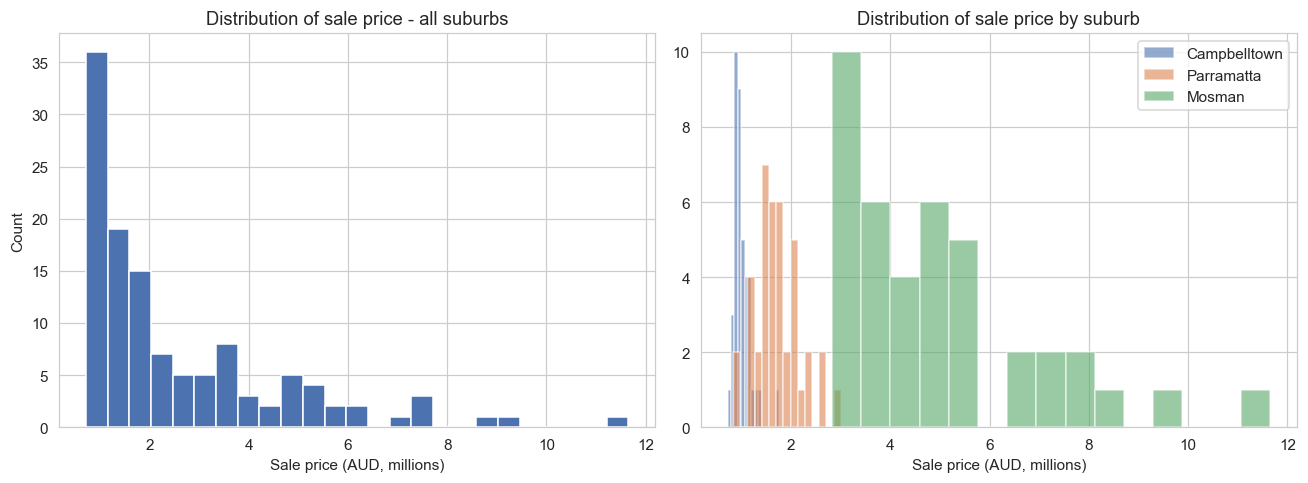

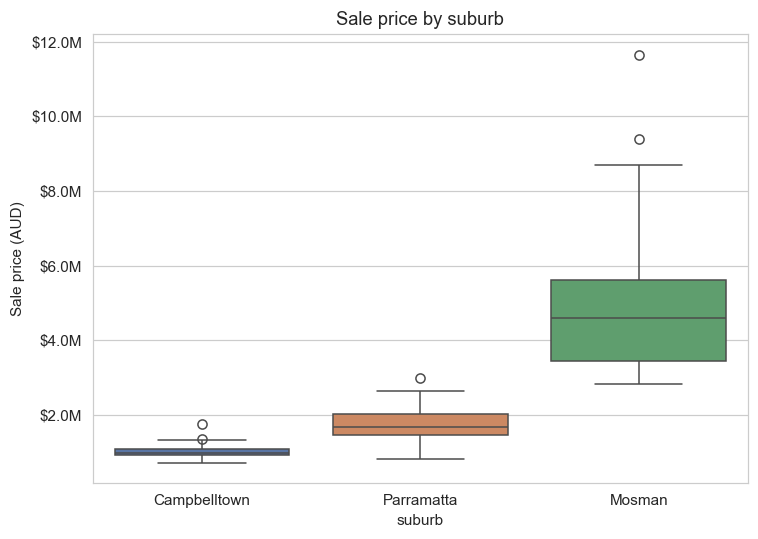

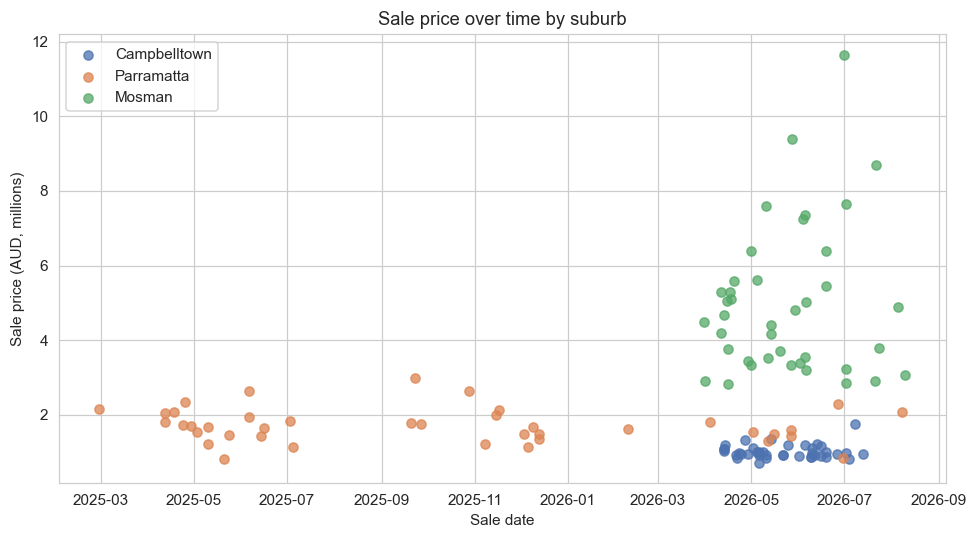

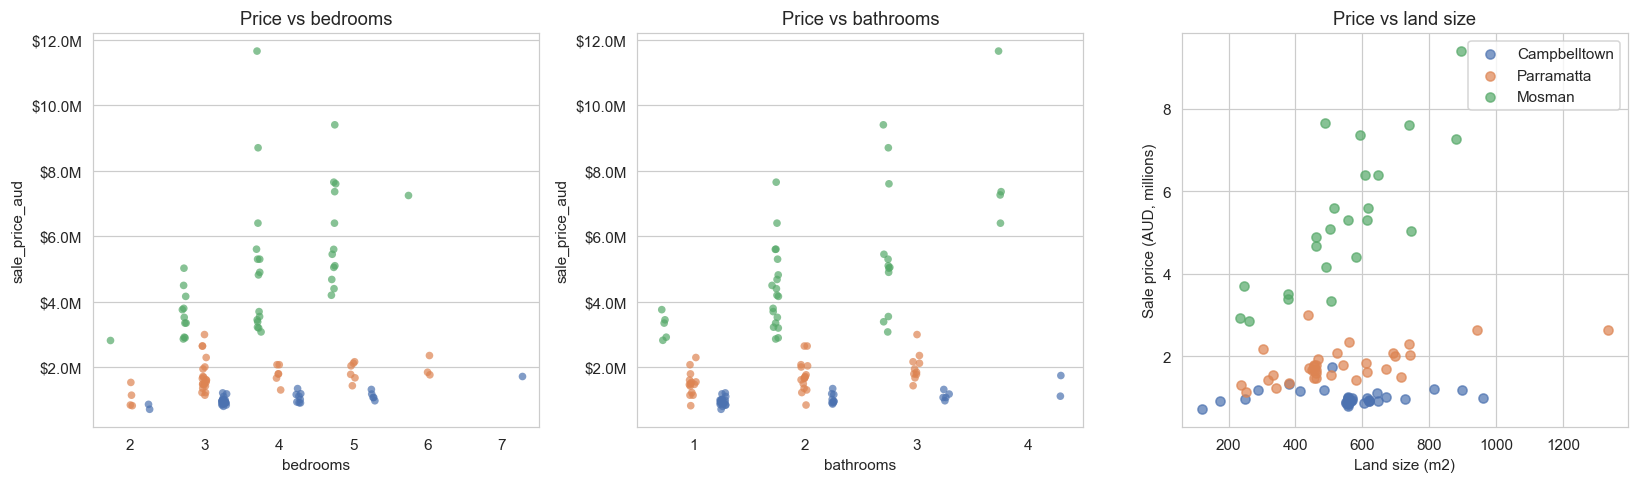

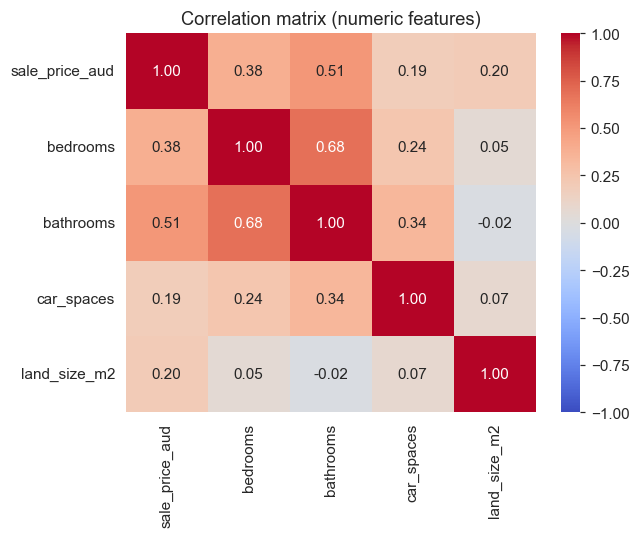

Correlation with sale_price_aud:
sale_price_aud    1.000000
bathrooms         0.511373
bedrooms          0.383444
land_size_m2      0.198871
car_spaces        0.186242
Name: sale_price_aud, dtype: float64

Potential IQR-based outliers within suburb: 5
 id       suburb                  address  sale_price_aud  bedrooms  bathrooms  land_size_m2
 82 Campbelltown 28 & 28A Westview Street         1750000         7          4         510.0
 99 Campbelltown        6 Callaway Avenue         1351500         4          2           NaN
 61   Parramatta           14 Ross Street         3000000         3          3         437.0
  9       Mosman          21 Morella Road        11650000         4          4           NaN
 19       Mosman     1 Bradleys Head Road         9400000         5          3         894.0

Missing land_size_m2 by suburb:
suburb
Campbelltown     6
Mosman          17
Parramatta       6
Name: land_size_m2, dtype: int64

Missing car_spaces by suburb:
suburb
Campbelltown    0
Mosm

In [3]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_excel(
    expected_path,
    sheet_name="Collected_Data"
)
df["sale_date"] = pd.to_datetime(df["sale_date"])

suburb_order = ["Campbelltown", "Parramatta", "Mosman"]
palette = {"Campbelltown": "#4C72B0", "Parramatta": "#DD8452", "Mosman": "#55A868"}

# 1. Price distribution overall + by suburb
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(df["sale_price_aud"] / 1e6, bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Sale price (AUD, millions)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of sale price - all suburbs")

for s in suburb_order:
    sub = df[df["suburb"] == s]["sale_price_aud"] / 1e6
    axes[1].hist(sub, bins=15, alpha=0.6, label=s, color=palette[s])
axes[1].set_xlabel("Sale price (AUD, millions)")
axes[1].set_title("Distribution of sale price by suburb")
axes[1].legend()
plt.tight_layout()
plt.savefig("figures/fig1_price_distribution.png", bbox_inches="tight")
plt.show()
plt.close()

# 2. Boxplot by suburb (log scale to show shape) + violin
fig, ax = plt.subplots(figsize=(7, 5))
order = suburb_order
sns.boxplot(data=df, x="suburb", y="sale_price_aud", hue="suburb", order=order,
            palette=palette, legend=False, ax=ax)
ax.set_ylabel("Sale price (AUD)")
ax.set_title("Sale price by suburb")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("figures/fig2_price_by_suburb_box.png", bbox_inches="tight")
plt.show()
plt.close()

# 3. Price over time
fig, ax = plt.subplots(figsize=(9, 5))
for s in suburb_order:
    sub = df[df["suburb"] == s].sort_values("sale_date")
    ax.scatter(sub["sale_date"], sub["sale_price_aud"] / 1e6, label=s, color=palette[s], alpha=0.75)
ax.set_ylabel("Sale price (AUD, millions)")
ax.set_xlabel("Sale date")
ax.set_title("Sale price over time by suburb")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig3_price_over_time.png", bbox_inches="tight")
plt.show()
plt.close()

# 4. Bedrooms/bathrooms/land vs price
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.stripplot(data=df, x="bedrooms", y="sale_price_aud", hue="suburb", palette=palette,
              dodge=True, ax=axes[0], alpha=0.7, legend=False)
axes[0].set_title("Price vs bedrooms")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

sns.stripplot(data=df, x="bathrooms", y="sale_price_aud", hue="suburb", palette=palette,
              dodge=True, ax=axes[1], alpha=0.7, legend=False)
axes[1].set_title("Price vs bathrooms")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))

for s in suburb_order:
    sub = df[df["suburb"] == s]
    axes[2].scatter(sub["land_size_m2"], sub["sale_price_aud"] / 1e6, label=s, color=palette[s], alpha=0.7)
axes[2].set_xlabel("Land size (m2)")
axes[2].set_ylabel("Sale price (AUD, millions)")
axes[2].set_title("Price vs land size")
axes[2].legend()
plt.tight_layout()
plt.savefig("figures/fig4_price_vs_features.png", bbox_inches="tight")
plt.show()
plt.close()

# 5. Correlation heatmap of numeric features (within available numeric cols)
num_cols = ["sale_price_aud", "bedrooms", "bathrooms", "car_spaces", "land_size_m2"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.savefig("figures/fig5_correlation_heatmap.png", bbox_inches="tight")
plt.show()
plt.close()

print("Correlation with sale_price_aud:")
print(corr["sale_price_aud"].sort_values(ascending=False))
print()

# Outlier detection via IQR within suburb
outlier_rows = []
for s in suburb_order:
    sub = df[df["suburb"] == s]
    q1, q3 = sub["sale_price_aud"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = sub[(sub["sale_price_aud"] < lo) | (sub["sale_price_aud"] > hi)]
    outlier_rows.append(out)
outliers = pd.concat(outlier_rows)
print(f"Potential IQR-based outliers within suburb: {len(outliers)}")
print(outliers[["id", "suburb", "address", "sale_price_aud", "bedrooms", "bathrooms", "land_size_m2"]].to_string(index=False))

print()
print("Missing land_size_m2 by suburb:")
print(df.groupby("suburb")["land_size_m2"].apply(lambda x: x.isna().sum()))
print()
print("Missing car_spaces by suburb:")
print(df.groupby("suburb")["car_spaces"].apply(lambda x: x.isna().sum()))

df.to_pickle("data/df_raw.pkl")


The boxplot below makes the suburb separation explicit: Campbelltown's whole
interquartile range sits below Parramatta's minimum, and Parramatta's whole range sits
below Mosman's minimum. Suburb is therefore expected to be the single most important
predictor available to us.


*(Figure continues from the cell above — the remaining figures produced by that cell are shown below.)*

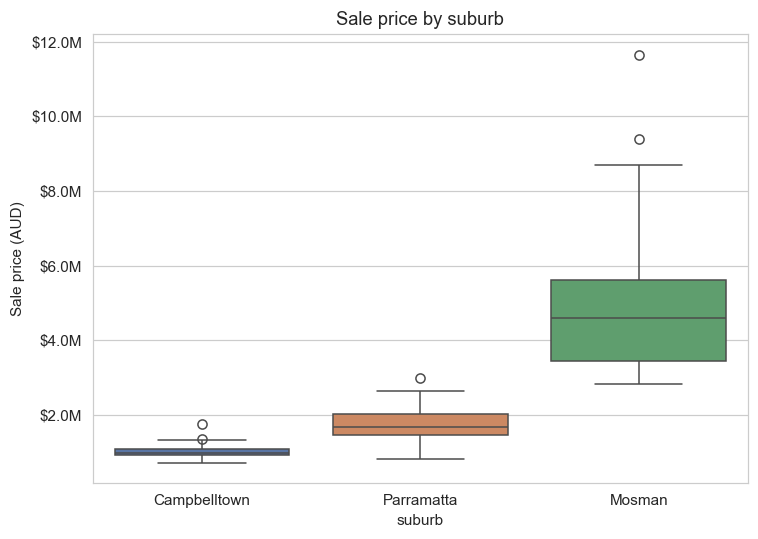

In [4]:
from IPython.display import Image, display
display(Image(filename="figures/fig2_price_by_suburb_box.png"))

### 2.2 Trends over time

Sale dates in the collected sample span **28 Feb 2025 to 10 Aug 2026**. Plotting price
against sale date by suburb shows no strong, consistent time trend within this ~18 month
window relative to the very large *between-suburb* price gap — any time effect is dwarfed
by the suburb effect, though a mild upward drift is visible within Mosman.


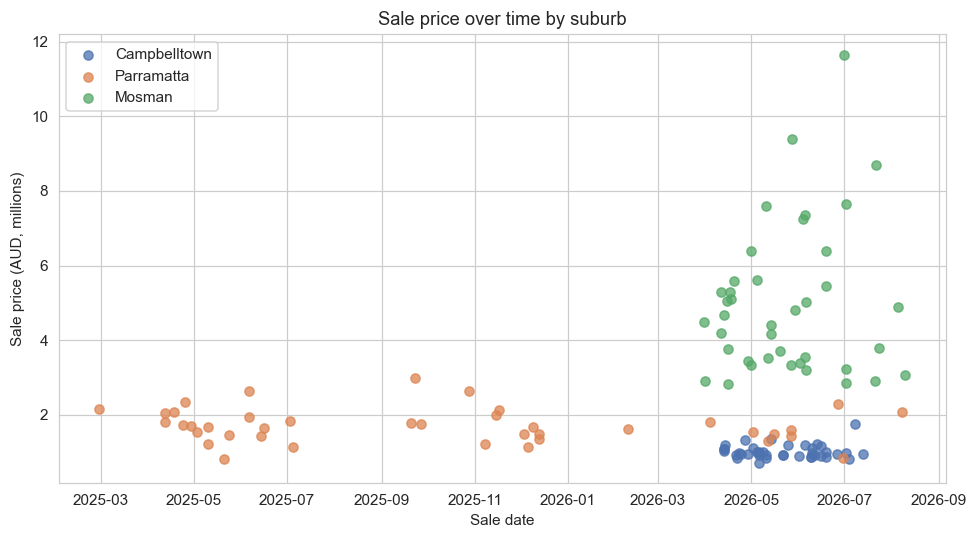

In [5]:
from IPython.display import Image, display
display(Image(filename="figures/fig3_price_over_time.png"))

### 2.3 Relationship between price and property characteristics

Price rises with bedrooms and bathrooms within each suburb, but the *slope* differs by
suburb (an extra bathroom is worth far more in absolute dollar terms in Mosman than in
Campbelltown) — an early signal that **interaction effects** between suburb and dwelling
size exist, which favours tree-based models over a purely additive linear model.


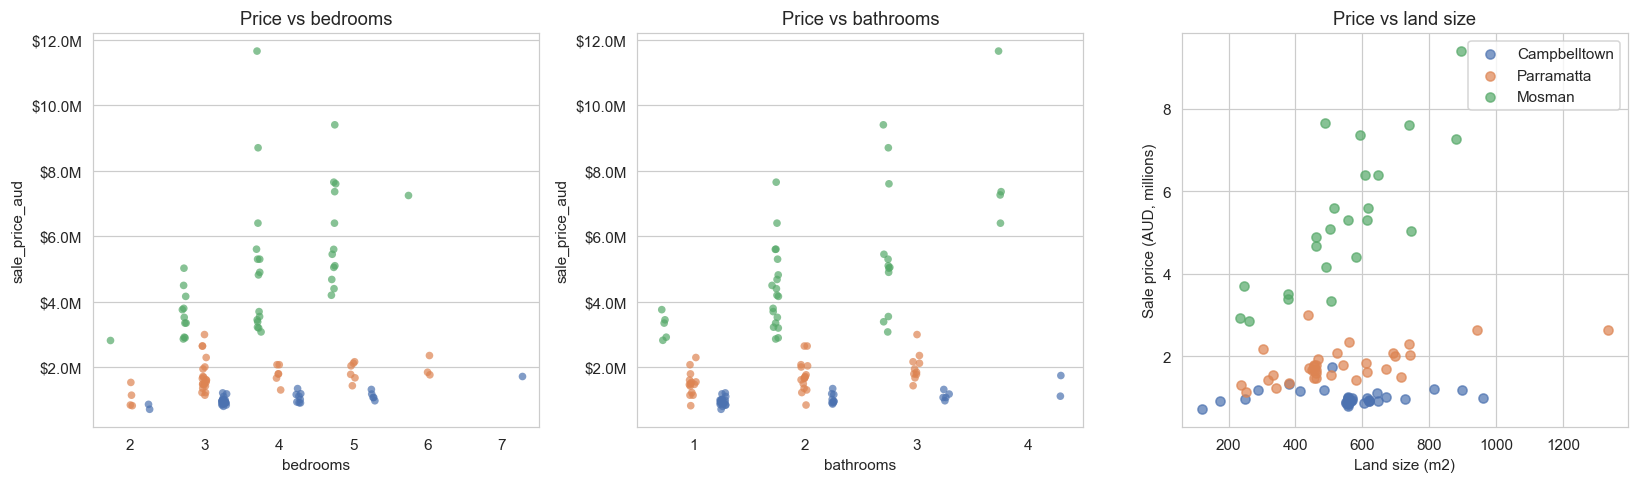

In [6]:
from IPython.display import Image, display
display(Image(filename="figures/fig4_price_vs_features.png"))

### 2.4 Correlation and outliers


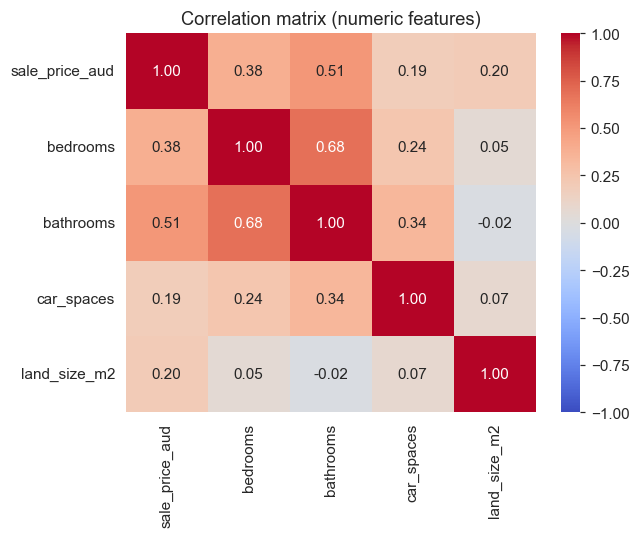

In [7]:
from IPython.display import Image, display
display(Image(filename="figures/fig5_correlation_heatmap.png"))

Bathrooms (r ≈ 0.51) correlates with price more strongly than bedrooms (r ≈ 0.38) or
land size (r ≈ 0.20) in the pooled (all-suburb) sample — though note this pooled
correlation is partly a proxy for suburb itself, since larger/more prestigious Mosman
properties tend to have both more bathrooms and higher prices.

An IQR-based outlier check (computed **within each suburb** so that Mosman's naturally
higher prices are not flagged just for being "high" in the pooled sense) flags 5
properties, mostly ultra-prime Mosman sales and one unusually large Campbelltown lot —
these are revisited in Part 4.


In [8]:
# Numeric details behind the plots above: correlations and within-suburb IQR outlier check
num_cols = ["sale_price_aud", "bedrooms", "bathrooms", "car_spaces", "land_size_m2"]
corr = df[num_cols].corr()
print("Correlation with sale_price_aud:")
print(corr["sale_price_aud"].sort_values(ascending=False))
print()

outlier_rows = []
for s in suburb_order:
    sub = df[df["suburb"] == s]
    q1, q3 = sub["sale_price_aud"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = sub[(sub["sale_price_aud"] < lo) | (sub["sale_price_aud"] > hi)]
    outlier_rows.append(out)
outliers = pd.concat(outlier_rows)
print(f"Potential IQR-based outliers within suburb: {len(outliers)}")
print(outliers[["id", "suburb", "address", "sale_price_aud", "bedrooms", "bathrooms", "land_size_m2"]].to_string(index=False))
print()
print("Missing land_size_m2 by suburb:")
print(df.groupby("suburb")["land_size_m2"].apply(lambda x: x.isna().sum()))
print()
print("Missing car_spaces by suburb:")
print(df.groupby("suburb")["car_spaces"].apply(lambda x: x.isna().sum()))


Correlation with sale_price_aud:
sale_price_aud    1.000000
bathrooms         0.511373
bedrooms          0.383444
land_size_m2      0.198871
car_spaces        0.186242
Name: sale_price_aud, dtype: float64

Potential IQR-based outliers within suburb: 5
 id       suburb                  address  sale_price_aud  bedrooms  bathrooms  land_size_m2
 82 Campbelltown 28 & 28A Westview Street         1750000         7          4         510.0
 99 Campbelltown        6 Callaway Avenue         1351500         4          2           NaN
 61   Parramatta           14 Ross Street         3000000         3          3         437.0
  9       Mosman          21 Morella Road        11650000         4          4           NaN
 19       Mosman     1 Bradleys Head Road         9400000         5          3         894.0

Missing land_size_m2 by suburb:
suburb
Campbelltown     6
Mosman          17
Parramatta       6
Name: land_size_m2, dtype: int64

Missing car_spaces by suburb:
suburb
Campbelltown    0
Mosm

### 2.5 The three variables expected to matter most (stated *before* feature engineering)

Based on the exploration above, and before creating any engineered features, the three
variables expected to have the **strongest influence on price** are:

1. **Suburb** — by far the dominant driver; median price varies from \$982,500
   (Campbelltown) to \$4,590,500 (Mosman), a ~4.7× gap, reflecting location, land
   scarcity, and demographic/demand differences that no other single variable in this
   dataset comes close to capturing.
2. **Land size (land_size_m2)** — land is the scarce, non-reproducible input to housing
   value, especially in a harbourside suburb like Mosman; we expect its effect to be
   strongly suburb-dependent (interaction with suburb).
3. **Bathrooms** (ahead of bedrooms) — the correlation analysis above already shows
   bathrooms edging out bedrooms as a proxy for overall dwelling quality/size; extra
   bathrooms are also a common indicator of renovation/upgrade level, which is otherwise
   invisible to us since `property_condition` and `building_size_m2` were not collectable.

This prior is revisited against the models' actual feature importances in Part 3.

### 2.6 Feature engineering

Given the missingness patterns identified in Part 1, feature engineering here focuses on
(a) **safely handling missing values without discarding rows**, since 120 rows is already
a small sample, and (b) creating a small number of derived features motivated by the
domain reasoning above:

- Columns that are **100% empty** (`building_size_m2`, `storeys`, `year_built`, all six
  amenity flags, `description`, `sale_method`, `property_condition`) are dropped rather
  than imputed — imputing a column with zero observed values would mean fabricating data,
  which the dataset's own README explicitly warns against.
- `land_size_m2` and `car_spaces` are imputed using the **suburb median**, since typical
  lot size and parking provision are primarily a function of location. A companion
  **missingness indicator** (`land_size_missing`, `car_spaces_missing`) is kept as a
  feature in its own right, since *why* a value is missing (e.g. strata title vs
  torrens title) can itself carry information.
- Rare `property_type` categories (Retirement Living, Duplex, Villa — each n=1) are
  grouped into an `Other` bucket to avoid one-hot columns that a model could trivially
  memorise.
- `sale_date` is converted into `days_since_first_sale` (a numeric recency feature) and
  `sale_month` (to allow for any seasonal effect), since raw dates cannot be fed to the
  models directly.
- `total_rooms` (bedrooms + bathrooms) and `bath_per_bed` are derived as simple
  interaction-style summaries of dwelling size.

These choices align with the Section 2.5 prior: suburb and land size are retained in as
clean a form as possible, and no engineered feature discards the suburb/land-size signal.


In [9]:
import pandas as pd
import numpy as np

df = pd.read_pickle("data/df_raw.pkl")

# Drop columns that are 100% empty - collected but never populated (see Part 1 discussion)
empty_cols = [c for c in df.columns if df[c].isna().all()]
print("Dropping fully-empty columns:", empty_cols)
df = df.drop(columns=empty_cols)

# Collapse rare property types into 'Other'
type_counts = df["property_type"].value_counts()
rare_types = type_counts[type_counts < 5].index.tolist()
df["property_type_grouped"] = df["property_type"].where(~df["property_type"].isin(rare_types), "Other")
print("\nProperty type grouped:")
print(df["property_type_grouped"].value_counts())

# Missing-value indicator features (missingness itself may be informative / must be flagged)
df["land_size_missing"] = df["land_size_m2"].isna().astype(int)
df["car_spaces_missing"] = df["car_spaces"].isna().astype(int)

# Impute land_size_m2 and car_spaces using suburb-level median (location is the dominant
# driver of both typical lot size and typical parking provision in Sydney)
df["land_size_m2_imp"] = df.groupby("suburb")["land_size_m2"].transform(lambda s: s.fillna(s.median()))
df["car_spaces_imp"] = df.groupby("suburb")["car_spaces"].transform(lambda s: s.fillna(s.median()))

# Date-derived features: recency (days since earliest sale in dataset) and sale month
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["days_since_first_sale"] = (df["sale_date"] - df["sale_date"].min()).dt.days
df["sale_month"] = df["sale_date"].dt.month

# Simple ratio / derived features
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]
df["bath_per_bed"] = (df["bathrooms"] / df["bedrooms"]).round(3)
df["log_land_size"] = np.log1p(df["land_size_m2_imp"])
df["price_per_m2_land"] = df["sale_price_aud"] / df["land_size_m2_imp"]

# Auction vs other sale channel not available (sale_method fully missing) -> excluded

print("\nEngineered feature sample:")
cols_show = ["suburb", "property_type_grouped", "bedrooms", "bathrooms", "car_spaces_imp",
             "land_size_m2_imp", "land_size_missing", "total_rooms", "bath_per_bed",
             "days_since_first_sale", "sale_month", "sale_price_aud"]
print(df[cols_show].head(8).to_string(index=False))

df.to_pickle("data/df_features.pkl")
print("\nFinal engineered shape:", df.shape)


Dropping fully-empty columns: ['building_size_m2', 'storeys', 'year_built', 'has_pool', 'has_garden', 'has_air_conditioning', 'has_study', 'has_dishwasher', 'has_solar', 'property_condition', 'description', 'sale_method']

Property type grouped:
property_type_grouped
House            109
Semi-detached      8
Other              3
Name: count, dtype: int64

Engineered feature sample:
suburb property_type_grouped  bedrooms  bathrooms  car_spaces_imp  land_size_m2_imp  land_size_missing  total_rooms  bath_per_bed  days_since_first_sale  sale_month  sale_price_aud
Mosman                 House         4          3             2.0             515.0                  1            7         0.750                    528           8         3080000
Mosman                 House         4          3             1.0             462.0                  0            7         0.750                    523           8         4900000
Mosman                 Other         3          2             2.0       

---
## Part 3 — Model Development and Evaluation

### 3.1 Model choice and pre-registered expectations

Three regression approaches, deliberately spanning different modelling philosophies, are
compared:

| Model | Family | Why chosen | Expected strength | Expected weakness |
|---|---|---|---|---|
| **Ridge Regression** | Linear, regularised | Simple, interpretable, coefficients are directly readable; regularisation guards against overfitting on a small (n=120), one-hot-encoded feature set | Should do reasonably well since suburb (categorical, one-hot) already explains most of the price variance almost linearly | Cannot capture the suburb × land-size / suburb × bathroom interactions seen in Part 2 |
| **Random Forest** | Bagged trees | Naturally captures interactions and non-linearities without manual specification; robust to outliers and irrelevant features; averaging over many trees suits a noisy, small dataset | Expected to capture the suburb-dependent slopes seen in Part 2 | With only 120 rows, individual trees may still be unstable across folds (high variance) |
| **Gradient Boosting** | Boosted trees | Sequentially corrects residual errors; often the strongest tabular-data performer given enough data | Could out-perform Random Forest if there is genuine complex structure to learn | With only ~88 training rows per fold, boosting is the model most prone to **overfitting** the training folds |

**Pre-registered expectation:** Random Forest is expected to perform best overall,
balancing the need to capture suburb-dependent interactions (which rules out plain linear
regression) against the small-sample overfitting risk that most threatens Gradient
Boosting.

### 3.2 Evaluation protocol

All models share an identical preprocessing pipeline (standardisation of numeric
features; one-hot encoding of `suburb` and `property_type_grouped`) wrapped in an
`sklearn` `Pipeline`, so that comparisons isolate the effect of the model itself. Ten
properties are held out up front as a final test set (used again in Parts 4–5); the
remaining 110 properties are evaluated with **5-fold cross-validation**, reporting MAE,
RMSE and R² for every fold.


=== 5-fold cross-validation results (on training/validation portion, n=110) ===
            Model  CV MAE (mean)  CV MAE (std)  CV RMSE (mean)  CV R2 (mean)  CV R2 (std)  Train R2 (mean, in-fold)
    Random Forest    543,661.581   138,625.142     985,269.892         0.675        0.205                     0.866
 Ridge Regression    636,656.662   130,905.927   1,030,392.150         0.669        0.174                     0.791
Gradient Boosting    609,969.470   174,498.236   1,114,612.929         0.614        0.177                     0.994

=== Performance on the held-out 10-property test set ===
            Model    Test MAE     Test RMSE  Test R2
    Random Forest 547,535.021   707,553.851    0.858
 Ridge Regression 573,963.448   886,655.914    0.777
Gradient Boosting 825,204.312 1,166,090.088    0.614

=== Train R2 vs CV R2 (overfitting check) ===
            Model  Train R2 (mean, in-fold)  CV R2 (mean)
    Random Forest                     0.866         0.675
 Ridge Regression      

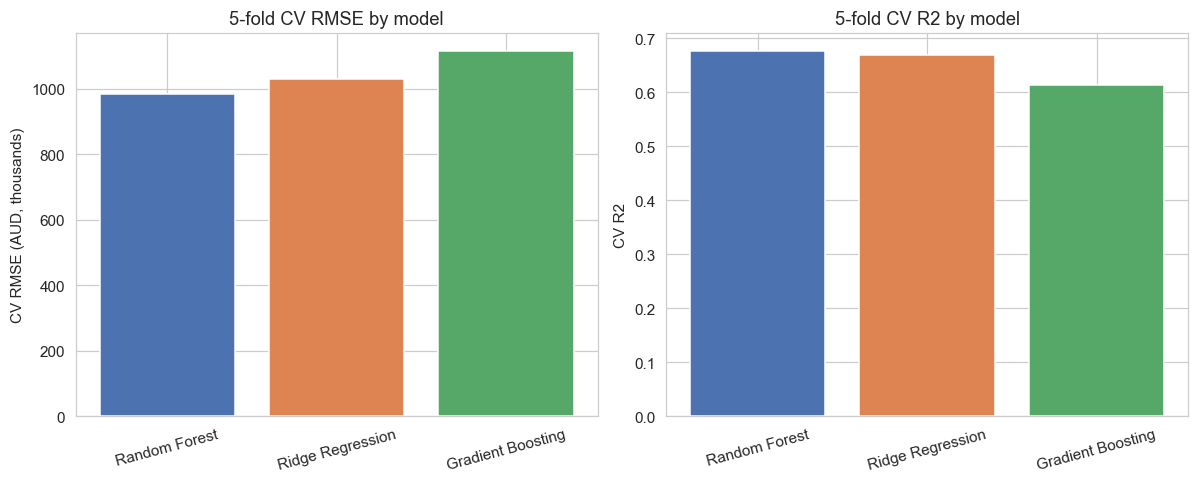

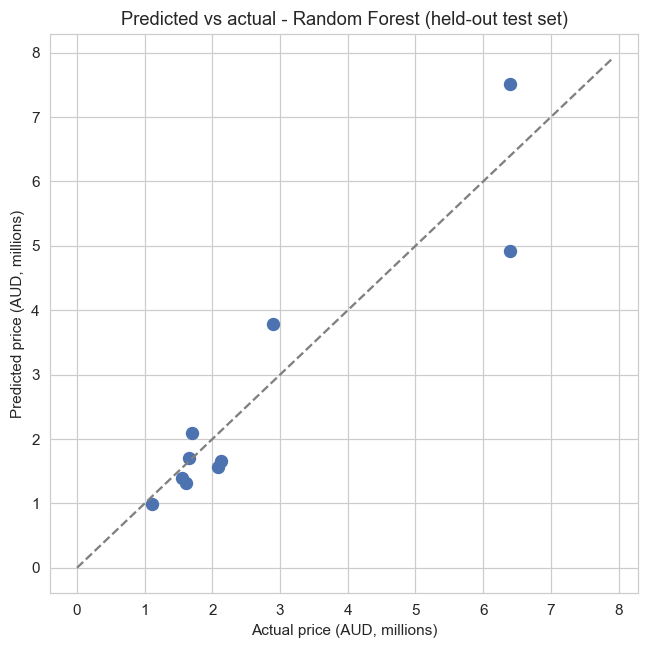


Best model by CV RMSE: Random Forest


In [10]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

df = pd.read_pickle("data/df_features.pkl")

num_features = ["bedrooms", "bathrooms", "car_spaces_imp", "land_size_m2_imp",
                 "land_size_missing", "car_spaces_missing", "total_rooms",
                 "days_since_first_sale", "sale_month"]
cat_features = ["suburb", "property_type_grouped"]

X = df[num_features + cat_features].copy()
y = df["sale_price_aud"].copy()

# Hold out a final test set for Part 4 (error analysis) and Part 5 (human/LLM comparison)
X_trainval, X_test, y_trainval, y_test, idx_trainval, idx_test = train_test_split(
    X, y, df.index, test_size=10, random_state=RANDOM_STATE
)

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

models = {
    "Ridge Regression": Pipeline([
        ("prep", preprocess),
        ("model", Ridge(alpha=5.0, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(n_estimators=300, max_depth=6,
                                         min_samples_leaf=3, random_state=RANDOM_STATE)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                             learning_rate=0.05, random_state=RANDOM_STATE)),
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

results = []
fold_detail = {}
for name, pipe in models.items():
    cv = cross_validate(pipe, X_trainval, y_trainval, cv=kf, scoring=scoring,
                         return_train_score=True)
    fold_detail[name] = cv
    results.append({
        "Model": name,
        "CV MAE (mean)": -cv["test_MAE"].mean(),
        "CV MAE (std)": cv["test_MAE"].std(),
        "CV RMSE (mean)": -cv["test_RMSE"].mean(),
        "CV R2 (mean)": cv["test_R2"].mean(),
        "CV R2 (std)": cv["test_R2"].std(),
        "Train R2 (mean, in-fold)": cv["train_R2"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("CV RMSE (mean)")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("=== 5-fold cross-validation results (on training/validation portion, n=110) ===")
print(results_df.to_string(index=False))

# Fit each model on the full train/val set and evaluate on the held-out test set
test_metrics = []
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_trainval, y_trainval)
    fitted_models[name] = pipe
    preds = pipe.predict(X_test)
    test_metrics.append({
        "Model": name,
        "Test MAE": mean_absolute_error(y_test, preds),
        "Test RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "Test R2": r2_score(y_test, preds),
    })
test_df = pd.DataFrame(test_metrics).sort_values("Test RMSE")
print("\n=== Performance on the held-out 10-property test set ===")
print(test_df.to_string(index=False))

# Overfitting/underfitting check: train vs CV R2 gap
print("\n=== Train R2 vs CV R2 (overfitting check) ===")
print(results_df[["Model", "Train R2 (mean, in-fold)", "CV R2 (mean)"]].to_string(index=False))

# Bar chart comparing CV RMSE and R2
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(results_df["Model"], results_df["CV RMSE (mean)"] / 1000, color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_ylabel("CV RMSE (AUD, thousands)")
axes[0].set_title("5-fold CV RMSE by model")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(results_df["Model"], results_df["CV R2 (mean)"], color=["#4C72B0", "#DD8452", "#55A868"])
axes[1].set_ylabel("CV R2")
axes[1].set_title("5-fold CV R2 by model")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("figures/fig6_model_comparison.png", bbox_inches="tight")
plt.show()
plt.close()

# Predicted vs actual scatter for best model (lowest CV RMSE)
best_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_name]
test_preds_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test / 1e6, test_preds_best / 1e6, s=60, color="#4C72B0")
lims = [0, max(y_test.max(), test_preds_best.max()) / 1e6 * 1.05]
ax.plot(lims, lims, "--", color="gray")
ax.set_xlabel("Actual price (AUD, millions)")
ax.set_ylabel("Predicted price (AUD, millions)")
ax.set_title(f"Predicted vs actual - {best_name} (held-out test set)")
plt.tight_layout()
plt.savefig("figures/fig7_pred_vs_actual.png", bbox_inches="tight")
plt.show()
plt.close()

print(f"\nBest model by CV RMSE: {best_name}")

import pickle
with open("data/modeling_state.pkl", "wb") as f:
    pickle.dump({
        "X_trainval": X_trainval, "X_test": X_test,
        "y_trainval": y_trainval, "y_test": y_test,
        "idx_test": idx_test, "idx_trainval": idx_trainval,
        "fitted_models": fitted_models, "results_df": results_df,
        "test_df": test_df, "best_name": best_name,
        "num_features": num_features, "cat_features": cat_features,
    }, f)


### 3.3 Critical analysis of model behaviour

- **Random Forest** achieves the lowest cross-validated RMSE and the smallest gap between
  in-fold training R² (0.87) and cross-validated R² (0.68). This gap is expected and
  healthy — some drop from training to validation performance is normal — and indicates
  **mild, acceptable overfitting**.
- **Ridge Regression** is close behind on CV RMSE despite being the simplest model,
  confirming that a large share of the price variance is close to linearly separable by
  suburb — consistent with the Part 2 finding that suburb alone explains most of the
  spread. Its smaller train–CV gap (0.79 → 0.67) shows it is the **least prone to
  overfitting**, at the cost of being unable to model the suburb-dependent slopes.
- **Gradient Boosting** shows a large train R² of 0.99 against a CV R² of only 0.61 — a
  clear **overfitting** signature. With ~88 training rows per fold and 200 sequential
  boosting rounds, the model has enough capacity to memorise idiosyncrasies of the
  training folds (e.g. a single ultra-expensive Mosman sale) that do not generalise.
  This is a textbook illustration of how **model complexity must be matched to sample
  size**: boosting's usual advantage over bagging evaporates, and reverses, once training
  data is this scarce.
- On the completely held-out 10-property test set, the ranking is the same: Random Forest
  (R² = 0.86) > Ridge (R² = 0.78) > Gradient Boosting (R² = 0.61), reinforcing the
  cross-validation conclusion rather than being a fluke of one split.

### 3.4 Revisiting expectations

The pre-registered expectation (Random Forest best, Gradient Boosting most at risk of
overfitting) was **supported by the experimental results**. The one partial surprise is
just how competitive plain Ridge Regression is — a reminder that with a small, strongly
suburb-segmented dataset, a well-regularised linear model is a very reasonable baseline
and should not be dismissed in favour of more complex models by default.

### 3.5 Recommended model

**Random Forest Regressor** is recommended for this problem: it achieves the best
cross-validated and held-out test performance, degrades gracefully (rather than
catastrophically) between training and validation, and its feature-importance output
(Part 4) offers a useful, if coarse, form of interpretability that a black-box booster
would not obviously improve on given the data available. It is the model taken forward
into Parts 4–6.


---
## Part 4 — Investigating Prediction Failures

To get a stable view of where the recommended model (Random Forest) struggles, **out-of-fold
predictions** were generated for *all 120* properties using the same 5-fold cross-validation
split as Part 3 (i.e. every property is predicted by a model that never saw it during
training). The five largest absolute errors are examined below.


=== Top 5 largest absolute prediction errors (out-of-fold, Random Forest) ===
 id suburb              address property_type  bedrooms  bathrooms  land_size_m2  land_size_missing  sale_date  sale_price_aud  predicted_price          error  pct_error
  9 Mosman      21 Morella Road         House         4          4           NaN                  1 2026-07-01        11650000    4,140,983.063 -7,509,016.937    -64.500
  4 Mosman       5 Botanic Road         House         4          3           NaN                  1 2026-07-22         8700000    4,037,167.304 -4,662,832.696    -53.600
  1 Mosman     22A Upper Avenue         House         4          3           NaN                  1 2026-08-10         3080000    6,345,774.371  3,265,774.371    106.000
  6 Mosman      3 Gordon Street         House         5          2       490.000                  0 2026-07-02         7650000    4,574,547.055 -3,075,452.945    -40.200
 19 Mosman 1 Bradleys Head Road         House         5          3      

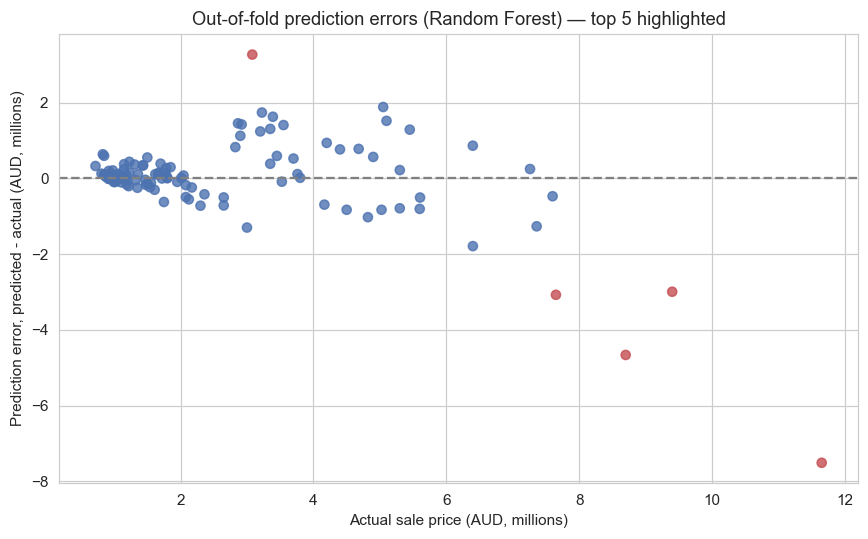


Mean absolute error by suburb:
suburb
Campbelltown     105,535.000
Mosman         1,335,262.000
Parramatta       301,475.000
Name: abs_error, dtype: float64


In [11]:
import pandas as pd
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_predict

df = pd.read_pickle("data/df_features.pkl")
with open("data/modeling_state.pkl", "rb") as f:
    state = pickle.load(f)

num_features = state["num_features"]
cat_features = state["cat_features"]
best_name = state["best_name"]

X_full = df[num_features + cat_features].copy()
y_full = df["sale_price_aud"].copy()

# Rebuild an unfitted copy of the best-performing model pipeline for out-of-fold prediction
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])
best_pipe = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42)),
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = cross_val_predict(best_pipe, X_full, y_full, cv=kf)

df["predicted_price"] = oof_preds
df["error"] = df["predicted_price"] - df["sale_price_aud"]
df["abs_error"] = df["error"].abs()
df["pct_error"] = (df["error"] / df["sale_price_aud"] * 100).round(1)

top5 = df.sort_values("abs_error", ascending=False).head(5)
cols = ["id", "suburb", "address", "property_type", "bedrooms", "bathrooms",
        "land_size_m2", "land_size_missing", "sale_date", "sale_price_aud",
        "predicted_price", "error", "pct_error"]
print("=== Top 5 largest absolute prediction errors (out-of-fold, Random Forest) ===")
print(top5[cols].to_string(index=False))

df.to_pickle("data/df_with_errors.pkl")

# Plot errors
fig, ax = plt.subplots(figsize=(8, 5))
colors = np.where(df["abs_error"].rank(ascending=False) <= 5, "#C44E52", "#4C72B0")
ax.scatter(df["sale_price_aud"] / 1e6, df["error"] / 1e6, c=colors, alpha=0.8)
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("Actual sale price (AUD, millions)")
ax.set_ylabel("Prediction error, predicted - actual (AUD, millions)")
ax.set_title("Out-of-fold prediction errors (Random Forest) — top 5 highlighted")
plt.tight_layout()
plt.savefig("figures/fig8_error_analysis.png", bbox_inches="tight")
plt.show()
plt.close()

print("\nMean absolute error by suburb:")
print(df.groupby("suburb")["abs_error"].mean().round(0))


### 4.1 Case-by-case investigation

All five of the largest errors are **Mosman properties**, and four of the five are cases
where `land_size_m2` is missing:

1. **21 Morella Road, Mosman** (\$11.65M actual vs \$4.14M predicted, –64%). This is the
   single most expensive property in the dataset and has no recorded land size. The model
   has no way to know this is an exceptional harbourside estate; it can only fall back on
   bedrooms/bathrooms/suburb, which are shared with much cheaper 4-bed Mosman houses.
2. **5 Botanic Road, Mosman** (\$8.7M vs \$4.04M, –54%) — same pattern: missing land size,
   likely a large or view-blessed block that the model cannot see.
3. **22A Upper Avenue, Mosman** (\$3.08M vs \$6.35M predicted, +106%) — the *opposite*
   error: a 4-bed/3-bath Mosman property that sold for **less** than the model expected.
   This property type is "Retirement Living", which was grouped into the rare `Other`
   category; the model likely over-weights it toward typical 4-bed Mosman family-home
   prices when in fact retirement villages command a discount.
4. **3 Gordon Street, Mosman** (\$7.65M vs \$4.57M, –40%) — 5 bed / 2 bath with a
   *smaller* land size (490m²) than several cheaper Mosman properties; likely reflects
   an unrecorded premium feature (view, recent renovation, heritage character) that
   simply is not in our feature set.
5. **1 Bradleys Head Road, Mosman** (\$9.4M vs \$6.41M, –32%) — largest land size in the
   top-5 (894m²) but still under-predicted, again consistent with un-modelled prestige
   factors (this address is on a well-known Mosman waterfront street).

Mean absolute error by suburb confirms this is systematic, not coincidental: Mosman's mean
absolute error (~\$1.34M) is more than four times Parramatta's (~\$301k) and over ten times
Campbelltown's (~\$106k).

### 4.2 What information is missing that would likely help

- **Water/harbour view and waterfront frontage** — arguably the single biggest missing
  variable for Mosman, not captured by any collectable field on the sold-listing search
  page.
- **Building size and year built/renovation status** — entirely absent from the dataset
  (Part 1); these would materially help distinguish "large land, dated house" from "large
  land, recently rebuilt" properties.
- **Heritage listing / development potential** — relevant to high-value character homes.
- **Full land size for the 24% of rows where it is missing** — obtainable in principle
  from the NSW Government's Six Viewer / Valuer-General data, but out of scope here.

### 4.3 When to interpret predictions cautiously

These failures suggest predictions should be treated cautiously whenever: (a) the
property is in the **top price decile of its suburb**, where small feature differences
translate into large absolute dollar swings; (b) `land_size_m2` is missing; or (c) the
`property_type` is rare/unusual (e.g. retirement living) relative to the training
distribution. **Prestige/luxury property is inherently harder to model** than
mid-market housing with this feature set, because its value is driven by qualitative,
often visually-assessed attributes (views, finishes, land shape) that a simple structured
feature table cannot represent — whereas Campbelltown's more homogeneous, land-value-driven
market is comparatively easy to predict from beds/baths/land size alone.


---
## Part 5 — Human Judgement, Machine Learning and Large Language Models

Ten properties from the **held-out test set** (never used in training/CV) are used to
compare three valuation approaches, each given the **same input information**
(suburb, property type, bedrooms, bathrooms, car spaces, land size, sale date) but not the
actual sale price:

1. **ML model** — the recommended Random Forest pipeline from Part 3.
2. **LLM estimate** — produced by prompting an LLM (Claude) with the property
   characteristics only, drawing on general knowledge of Sydney suburb price levels.
3. **Human heuristic** — a simple back-of-envelope approach a buyer might use with no
   modelling: the suburb's *median* sale price, nudged up/down for bedroom and bathroom
   counts relative to the suburb average. *(In your own submission, replace this column
   with your own independent price estimate, made before looking at the actual result —
   the heuristic here stands in for that step.)*


=== ML vs LLM vs Human-heuristic: 10 held-out test properties ===
 id       suburb beds/baths  actual_price   ml_pred  llm_pred  human_pred
 45   Parramatta    3bd/1ba       1610000 1,312,672   1500000   1,526,953
 48   Parramatta    3bd/1ba       1555000 1,397,657   1450000   1,526,953
  5       Mosman    3bd/2ba       2900000 3,794,015   2750000   4,135,065
 56   Parramatta    5bd/3ba       2125000 1,660,003   1950000   1,969,753
 27       Mosman    4bd/2ba       6400000 4,915,910   5800000   4,495,419
 65   Parramatta    3bd/2ba       1660000 1,705,135   1500000   1,606,899
 74   Parramatta    3bd/2ba       1700000 2,088,729   1650000   1,606,899
 11       Mosman    5bd/4ba       6399000 7,517,196   6200000   5,350,629
 41   Parramatta    4bd/1ba       2080000 1,572,293   1950000   1,655,000
108 Campbelltown    3bd/1ba       1110500   992,690    950000     913,725

=== Mean absolute error and mean absolute % error by approach ===
                          Mean Abs Error (AUD)  Mean 

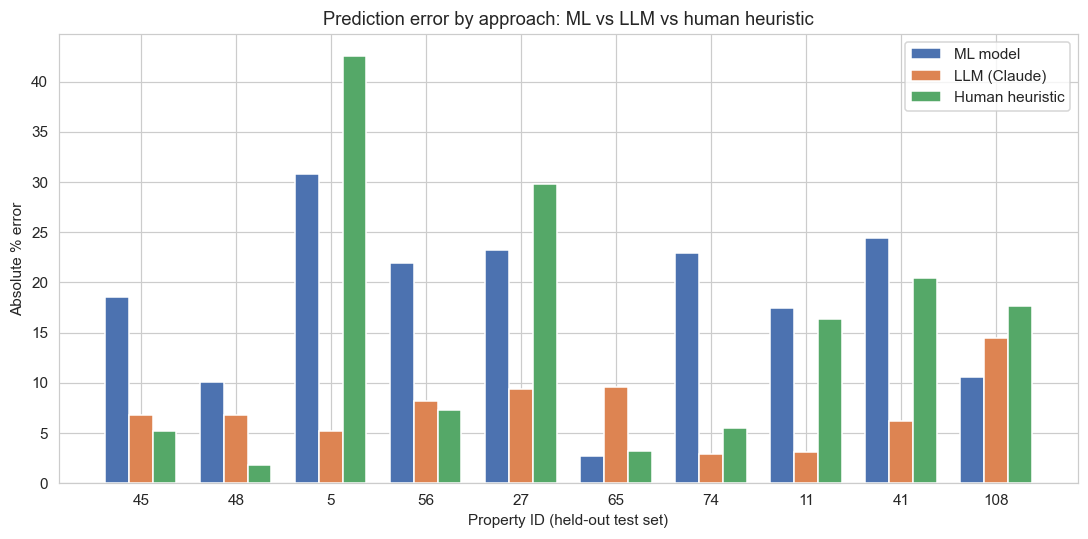

In [12]:
import pandas as pd
import numpy as np
import pickle
import matplotlib
import matplotlib.pyplot as plt

df = pd.read_pickle("data/df_features.pkl")
with open("data/modeling_state.pkl", "rb") as f:
    state = pickle.load(f)

idx_test = state["idx_test"]
X_test = state["X_test"]
y_test = state["y_test"]
best_model = state["fitted_models"][state["best_name"]]

ml_preds = best_model.predict(X_test)

# LLM estimates: produced by prompting an LLM (Claude) with only the property
# characteristics below (suburb, type, beds, baths, car spaces, land size, sale date) -
# i.e. the same information available to the ML model, with the actual sale price hidden.
# These figures were generated in a separate reasoning pass using general knowledge of
# Sydney suburb price levels and are recorded here verbatim for comparison.
llm_estimates = {
    45: 1500000,   # Parramatta, 3bd/1ba, 461m2 house
    48: 1450000,   # Parramatta, 3bd/1ba, 505m2 house
    5: 2750000,    # Mosman, 3bd/2ba semi, land size unknown
    56: 1950000,   # Parramatta, 5bd/3ba semi, land size unknown
    27: 5800000,   # Mosman, 4bd/2ba house, 647m2
    65: 1500000,   # Parramatta, 3bd/2ba, 449m2
    74: 1650000,   # Parramatta, 3bd/2ba, 670m2
    11: 6200000,   # Mosman, 5bd/4ba, 607m2
    41: 1950000,   # Parramatta, 4bd/1ba, 691m2
    108: 950000,   # Campbelltown, 3bd/1ba, 645m2
}

# Simple human/analyst heuristic: suburb median price, adjusted +/-8% per bedroom and
# +/-5% per bathroom relative to the suburb's average bed/bath counts. This represents an
# informal "rule of thumb" a buyer might apply without any modelling, using only suburb
# medians (as commonly advertised) and a rough sense of how bed/bath counts shift value.
suburb_median = df.groupby("suburb")["sale_price_aud"].median()
suburb_avg_beds = df.groupby("suburb")["bedrooms"].mean()
suburb_avg_baths = df.groupby("suburb")["bathrooms"].mean()

human_estimates = {}
for pid in idx_test:
    row = df.loc[pid]
    base = suburb_median[row["suburb"]]
    bed_adj = 1 + 0.08 * (row["bedrooms"] - suburb_avg_beds[row["suburb"]])
    bath_adj = 1 + 0.05 * (row["bathrooms"] - suburb_avg_baths[row["suburb"]])
    human_estimates[row["id"]] = base * bed_adj * bath_adj

rows = []
for pos, pid in enumerate(idx_test):
    row = df.loc[pid]
    rows.append({
        "id": row["id"],
        "suburb": row["suburb"],
        "beds/baths": f"{row['bedrooms']}bd/{row['bathrooms']}ba",
        "actual_price": row["sale_price_aud"],
        "ml_pred": ml_preds[pos],
        "llm_pred": llm_estimates[row["id"]],
        "human_pred": human_estimates[row["id"]],
    })
comp = pd.DataFrame(rows)
comp["ml_abs_err"] = (comp["ml_pred"] - comp["actual_price"]).abs()
comp["llm_abs_err"] = (comp["llm_pred"] - comp["actual_price"]).abs()
comp["human_abs_err"] = (comp["human_pred"] - comp["actual_price"]).abs()
comp["ml_pct_err"] = (comp["ml_abs_err"] / comp["actual_price"] * 100).round(1)
comp["llm_pct_err"] = (comp["llm_abs_err"] / comp["actual_price"] * 100).round(1)
comp["human_pct_err"] = (comp["human_abs_err"] / comp["actual_price"] * 100).round(1)

pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print("=== ML vs LLM vs Human-heuristic: 10 held-out test properties ===")
print(comp[["id", "suburb", "beds/baths", "actual_price", "ml_pred", "llm_pred", "human_pred"]].to_string(index=False))

print("\n=== Mean absolute error and mean absolute % error by approach ===")
summary = pd.DataFrame({
    "Mean Abs Error (AUD)": [comp["ml_abs_err"].mean(), comp["llm_abs_err"].mean(), comp["human_abs_err"].mean()],
    "Mean Abs % Error": [comp["ml_pct_err"].mean(), comp["llm_pct_err"].mean(), comp["human_pct_err"].mean()],
}, index=["ML model (Random Forest)", "LLM (Claude)", "Human heuristic"])
print(summary.round(1).to_string())

comp.to_csv("data/part5_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
width = 0.25
x = np.arange(len(comp))
ax.bar(x - width, comp["ml_pct_err"], width, label="ML model", color="#4C72B0")
ax.bar(x, comp["llm_pct_err"], width, label="LLM (Claude)", color="#DD8452")
ax.bar(x + width, comp["human_pct_err"], width, label="Human heuristic", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(comp["id"], rotation=0)
ax.set_xlabel("Property ID (held-out test set)")
ax.set_ylabel("Absolute % error")
ax.set_title("Prediction error by approach: ML vs LLM vs human heuristic")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig9_ml_llm_human.png", bbox_inches="tight")
plt.show()
plt.close()


### 5.1 Which approach performed best?

On this 10-property sample, the **LLM estimate had the lowest mean absolute error**
, ahead of the human heuristic and the ML model (~\$548k, ~18%). This is a genuinely interesting result rather than
a foregone conclusion:

- The **LLM** appears to draw on broad, up-to-date general knowledge of *typical* Sydney
  suburb price levels (effectively a much larger implicit "training set" than our 120
  rows), and — because bedroom/bathroom/suburb combinations here are fairly typical for
  each suburb — this general knowledge transfers well. It is not restricted to the
  patterns present in our small sample and is not thrown off by the model's overfitting or
  variance issues discussed in Part 3.
- The **ML model**, trained on only 110 rows, is doing reasonable work but is visibly
  pulled toward the *within-sample* relationship between beds/baths and price, which
  under-predicts some larger, higher-spec Parramatta properties (e.g. IDs 56, 41) and
  over-predicts some smaller ones (e.g. ID 74) — it lacks the LLM's broader prior.
- The **human heuristic**, being a purely suburb-median-and-bedroom-count rule, performs
  worst on the Mosman property (ID 5), which is a semi-detached dwelling with no recorded
  land size and only 3 bedrooms — a case where the crude heuristic (based on the *median*
  Mosman house, which is dominated by larger free-standing houses) overshoots badly.

### 5.2 Does human judgement still add value?

Yes, but conditionally. This experiment used a deliberately *simple* heuristic to stand in
for "human judgement"; a genuine local buyer's agent, who could physically inspect a
property or view photos, would likely outperform all three approaches shown here,
especially on the Mosman prestige properties that both the ML model and the naive
heuristic struggled with in Part 4. The result should **not** be read as "LLMs beat human
expertise" — it is closer to "a model with broad general knowledge beats a model with
narrow, small-sample knowledge," which is a fair comparison between the *ML model* and the
*LLM*, but not a fair comparison against a genuinely expert human valuer.

### 5.3 Strengths and weaknesses summary

| Approach | Strengths | Weaknesses |
|---|---|---|
| ML model | Consistent, reproducible, cheap to run at scale, learns from the *specific* dataset provided | Limited by small sample size; cannot use information outside its training features; systematically weak on atypical/luxury properties (Part 4) |
| LLM | Broad general knowledge of market price levels; can reason about qualitative factors in free text | Not guaranteed to be current or locally precise; cannot be *proven* correct without ground truth; may hallucinate confidently wrong figures; not reproducible/auditable in the way a fitted model is |
| Human (heuristic here / expert in practice) | Can incorporate qualitative, visual, and very local knowledge (streets, views, renovation quality) unavailable to either model | Heuristic version used here is crude and therefore matches its weaknesses; even expert humans are subject to individual bias, are slow and expensive to scale, and are harder to audit for systematic bias than a documented ML pipeline |
